# ML Training Pipeline
## Dự đoán Khủng hoảng Kinh tế Vĩ mô Toàn Cầu

**Mục tiêu:** Xây dựng một pipeline ML chuẩn Production để phân loại nhị phân:
- `is_crisis = 1`: Quốc gia đang trong hoặc sắp rơi vào khủng hoảng (GDP tăng trưởng < -2%)
- `is_crisis = 0`: Nền kinh tế bình thường

**Chiến lược:**
1. Benchmark 5 mô hình với tham số mặc định
2. Tối ưu hóa bằng Optuna (Bayesian Optimization)
3. Ensemble bằng Weighted Blending + Stacking
4. Đánh giá cuối cùng trên tập Test (2019-2024)
5. Giải thích AI bằng SHAP


In [2]:
# !pip install optuna
# !pip install imblearn
# !pip install warnings
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import json 
import warnings
import os 

# models 
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_class_weight
import xgboost as xgb 
import lightgbm as lgb 

# đánh giá 
from sklearn.metrics import (classification_report, roc_auc_score, confusion_matrix, f1_score, roc_curve, precision_recall_curve, average_precision_score)
from sklearn.model_selection import TimeSeriesSplit

# tuning 
import optuna 
optuna.logging.set_verbosity(optuna.logging.WARNING)

# explain 
import shap 

# imbalance 
from imblearn.over_sampling import SMOTE 


# config 
RANDOM_STATE = 42 
np.random.seed(RANDOM_STATE)
warnings.filterwarnings('ignore')

ML_DATA_DIR = "../airflow/dags/data/ml_data"
MODELS_DIR = "../models"

os.makedirs(MODELS_DIR, exist_ok=True)

print("Import thành công")


Import thành công


## Load dữ liệu

✅ Data Shapes | Train: (8390, 42) | Val: (1713, 42) | Test: (1240, 42)
✅ Số lượng Features: 42

 Phân phối các mức độ Rủi ro (Class Imbalance) trên tập Train:
  Class 0 (Low Risk): 66.75%
  Class 1 (Medium Risk): 27.03%
  Class 2 (High Risk): 6.22%


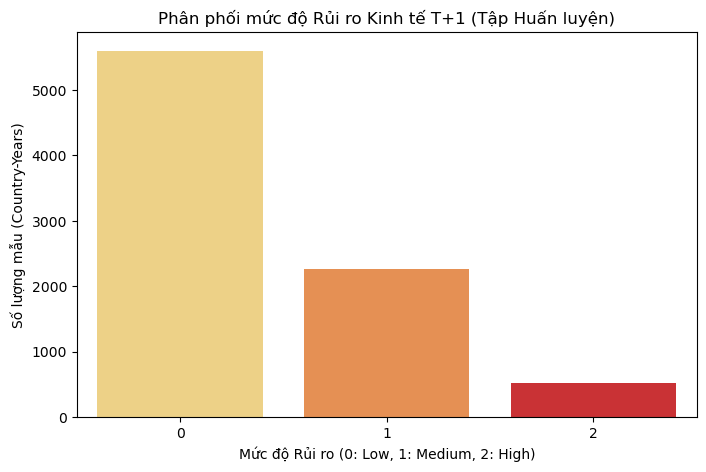

In [3]:
# Load 3 tập dữ liệu
train_df = pd.read_csv(f"{ML_DATA_DIR}/train.csv")
val_df   = pd.read_csv(f"{ML_DATA_DIR}/val.csv")
test_df  = pd.read_csv(f"{ML_DATA_DIR}/test.csv")

# Các cột không phải Feature
META_COLS = ['country_code', 'country_name', 'year', 'target_risk_next_year']

# Tách X và y
FEATURE_COLS = [c for c in train_df.columns if c not in META_COLS]

X_train, y_train = train_df[FEATURE_COLS], train_df['target_risk_next_year']
X_val,   y_val   = val_df[FEATURE_COLS],   val_df['target_risk_next_year']
X_test,  y_test  = test_df[FEATURE_COLS],  test_df['target_risk_next_year']
print(f"✅ Data Shapes | Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")
print(f"✅ Số lượng Features: {len(FEATURE_COLS)}\n")
# Phân tích Imbalance của Multi-class
print(" Phân phối các mức độ Rủi ro (Class Imbalance) trên tập Train:")
class_dist = y_train.value_counts(normalize=True).sort_index()
for risk_level, ratio in class_dist.items():
    print(f"  Class {risk_level} ({'Low' if risk_level==0 else 'Medium' if risk_level==1 else 'High'} Risk): {ratio*100:.2f}%")
# Vẽ biểu đồ trực quan hóa độ lệch nhãn
plt.figure(figsize=(8, 5))
sns.countplot(data=train_df, x='target_risk_next_year', palette='YlOrRd')
plt.title("Phân phối mức độ Rủi ro Kinh tế T+1 (Tập Huấn luyện)")
plt.xlabel("Mức độ Rủi ro (0: Low, 1: Medium, 2: High)")
plt.ylabel("Số lượng mẫu (Country-Years)")
plt.show()


## PART 2 — Baseline Benchmarking (Multi-class)

Với bài toán đa lớp (0, 1, 2) mất cân bằng cực nặng, chúng ta loại bỏ SMOTE (vì SMOTE rất dễ làm hỏng không gian phân loại đa chiều). Thay vào đó, chúng ta sẽ dùng kỹ thuật **Cost-Sensitive Learning (Trọng số lớp)** để ép model chú ý vào class hiếm.

**Metric so sánh chính: Multi-class ROC-AUC (One-vs-Rest) và Macro F1 trên tập Validation.**


In [5]:
# !pip install catboost
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier
import json
from sklearn.metrics import recall_score

RANDOM_STATE = 42
MODELS_DIR = "../airflow/dags/models"
os.makedirs(MODELS_DIR, exist_ok=True)

# Tính Class Weights (Trọng số phạt) cho tập Train
classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, weights))
sample_weights = y_train.map(class_weight_dict)

print(f"Trọng số Class: Low={class_weight_dict[0]:.2f}, Med={class_weight_dict[1]:.2f}, High={class_weight_dict[2]:.2f}")

# Định nghĩa các mô hình baseline ĐA LỚP
BASELINES = {
    "Logistic Regression": Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(
            class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE, multi_class='multinomial'
        ))
    ]),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1
    ),
    "XGBoost": xgb.XGBClassifier(
        objective='multi:softprob', num_class=3, random_state=RANDOM_STATE, eval_metric='mlogloss', verbosity=0
    ),
    "LightGBM": lgb.LGBMClassifier(
        n_estimators=200, class_weight='balanced', objective='multiclass', num_class=3, random_state=RANDOM_STATE, verbose=-1
    ),
    "CatBoost": CatBoostClassifier(
        iterations=200, loss_function='MultiClass', auto_class_weights='Balanced', random_seed=RANDOM_STATE, verbose=0
    )
}

# Huấn luyện và đánh giá
print("=" * 65)
print(f"{'Model':<25} {'AUC (OvR)':>10} {'Macro F1':>10} {'Recall_High':>12}")
print("=" * 65)

baseline_results = {}

for name, model in BASELINES.items():
    # XGBoost trong thư viện Sklearn API không có params class_weight='balanced', phải nhúng qua sample_weight
    if name == "XGBoost":
        model.fit(X_train, y_train, sample_weight=sample_weights)
    else:
        model.fit(X_train, y_train)
        
    y_prob = model.predict_proba(X_val)
    y_pred = model.predict(X_val)

    auc = roc_auc_score(y_val, y_prob, multi_class='ovr')
    f1  = f1_score(y_val, y_pred, average='macro')
    
    # Tính riêng Recall cho Class 2 (High Risk)
    # rec_high = (y_val.values == 2).sum() and (((y_pred == 2) & (y_val.values == 2)).sum() / (y_val.values == 2).sum())
    rec_high = recall_score(y_val, y_pred, average=None)[2]

    baseline_results[name] = {'model': model, 'auc': auc, 'f1': f1, 'recall': rec_high, 'prob': y_prob}
    print(f"{name:<25} {auc:>10.4f} {f1:>10.4f} {rec_high:>12.4f}")

print("=" * 65)

# Chọn model tốt nhất làm Baseline Champion
best_baseline = max(baseline_results, key=lambda k: baseline_results[k]['f1'])
print(f"\n Best Baseline: {best_baseline} (F1 = {baseline_results[best_baseline]['f1']:.4f})")


Trọng số Class: Low=0.50, Med=1.23, High=5.36
Model                      AUC (OvR)   Macro F1  Recall_High
Logistic Regression           0.8453     0.5605       0.6789
Random Forest                 0.9010     0.5888       0.1468
XGBoost                       0.8750     0.6031       0.2202
LightGBM                      0.8839     0.6273       0.2569
CatBoost                      0.8638     0.6081       0.2936

 Best Baseline: LightGBM (F1 = 0.6273)


## PART 3 — Hyperparameter Tuning đa lớp với Optuna

Chúng ta tối ưu XGBoost và LightGBM. Mục tiêu của Optuna là **Maximize Multi-class OvR AUC**.


In [6]:
# ---- OPTUNA CHO XGBOOST ----
def objective_xgb(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 800),
        'max_depth':         trial.suggest_int('max_depth', 3, 9),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'min_child_weight':  trial.suggest_int('min_child_weight', 1, 10),
        'objective':         'multi:softprob',
        'num_class':         3,
        'random_state':      RANDOM_STATE,
        'eval_metric':       'mlogloss',
        'verbosity':         0,
    }
    model = xgb.XGBClassifier(**params)
    model.fit(X_train, y_train, sample_weight=sample_weights)
    
    # Dự đoán xác suất cho 3 class
    y_prob = model.predict_proba(X_val)
    return roc_auc_score(y_val, y_prob, multi_class='ovr')

print("Đang tối ưu XGBoost... (100 trials)")
study_xgb = optuna.create_study(direction='maximize', study_name='xgb_tuning')
study_xgb.optimize(objective_xgb, n_trials=100, show_progress_bar=False)

print(f"\nXGBoost Best AUC: {study_xgb.best_value:.4f}")
print(f"Best Params: {study_xgb.best_params}")


Đang tối ưu XGBoost... (100 trials)

XGBoost Best AUC: 0.8991
Best Params: {'n_estimators': 626, 'max_depth': 8, 'learning_rate': 0.013136783252350948, 'subsample': 0.7402518786571751, 'colsample_bytree': 0.7142863195402465, 'reg_alpha': 0.0025603634476199563, 'reg_lambda': 0.3981666549226029, 'min_child_weight': 3}


In [7]:
# ---- OPTUNA CHO LIGHTGBM ----
def objective_lgb(trial):
    params = {
        'n_estimators':       trial.suggest_int('n_estimators', 100, 800),
        'num_leaves':         trial.suggest_int('num_leaves', 20, 300),
        'learning_rate':      trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'min_child_samples':  trial.suggest_int('min_child_samples', 5, 100),
        'feature_fraction':   trial.suggest_float('feature_fraction', 0.5, 1.0),
        'bagging_fraction':   trial.suggest_float('bagging_fraction', 0.5, 1.0),
        'bagging_freq':       trial.suggest_int('bagging_freq', 1, 7),
        'reg_alpha':          trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda':         trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'class_weight':       'balanced',
        'objective':          'multiclass',
        'num_class':          3,
        'random_state':       RANDOM_STATE,
        'verbose':            -1,
    }
    model = lgb.LGBMClassifier(**params)
    model.fit(X_train, y_train)
    
    y_prob = model.predict_proba(X_val)
    return roc_auc_score(y_val, y_prob, multi_class='ovr')

print("Đang tối ưu LightGBM... (100 trials)")
study_lgb = optuna.create_study(direction='maximize', study_name='lgb_tuning')
study_lgb.optimize(objective_lgb, n_trials=100, show_progress_bar=False)

print(f"\n LightGBM Best AUC: {study_lgb.best_value:.4f}")


Đang tối ưu LightGBM... (100 trials)

 LightGBM Best AUC: 0.9036


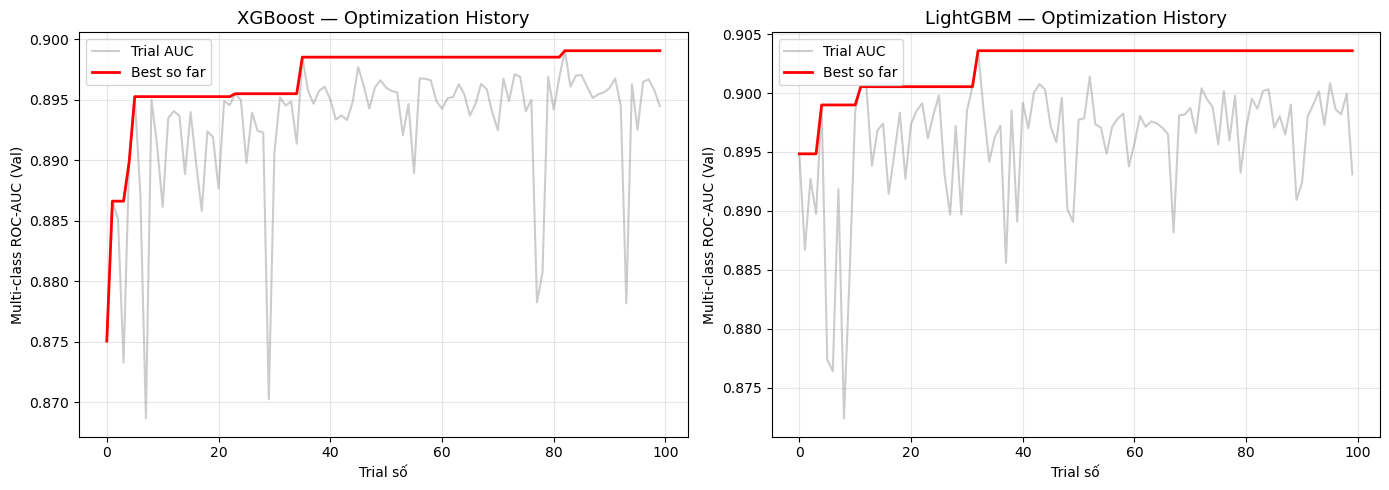

Đã lưu best params vào models/best_params.json


In [8]:
# Visualize Optuna Optimization History
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (study, name) in zip(axes, [(study_xgb, 'XGBoost'), (study_lgb, 'LightGBM')]):
    trials_auc = [t.value for t in study.trials]
    best_so_far = pd.Series(trials_auc).cummax()
    ax.plot(trials_auc, alpha=0.4, color='gray', label='Trial AUC')
    ax.plot(best_so_far.values, color='red', linewidth=2, label='Best so far')
    ax.set_title(f"{name} — Optimization History", fontsize=13)
    ax.set_xlabel("Trial số")
    ax.set_ylabel("Multi-class ROC-AUC (Val)")
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Lưu best params ra file
best_params = {
    'xgboost': study_xgb.best_params,
    'lightgbm': study_lgb.best_params
}
with open(f"{MODELS_DIR}/best_params.json", 'w') as f:
    json.dump(best_params, f, indent=2)
print("Đã lưu best params vào models/best_params.json")


## PART 4 — Walk-Forward Cross-Validation Đa lớp

Chúng ta sẽ mô phỏng lại khả năng dự báo của model qua các thời kỳ lịch sử. Với bài toán đa lớp, ta phải đảm bảo trọng số (Class Weights) được tính toán lại trong từng Fold để phản ánh đúng mức độ khan hiếm của các đợt Khủng hoảng trong từng thập kỷ.


In [9]:
# Gộp train + val để làm CV (Test vẫn bị giấu kín)
df_cv = pd.concat([train_df, val_df]).sort_values('year').reset_index(drop=True)
X_cv = df_cv[FEATURE_COLS]
y_cv = df_cv['target_risk_next_year']
years_cv = df_cv['year'].values

# Custom Walk-Forward: Chia theo năm
FOLD_BOUNDARIES = [1991, 1997, 2002, 2006, 2009, 2011]

print("=" * 65)
print(f"{'Fold':<8} {'Train Years':<20} {'Val Years':<20} {'AUC (OvR)':>10}")
print("=" * 65)

cv_scores = []
for i in range(len(FOLD_BOUNDARIES) - 1):
    train_mask = years_cv < FOLD_BOUNDARIES[i]
    val_mask   = (years_cv >= FOLD_BOUNDARIES[i]) & (years_cv < FOLD_BOUNDARIES[i+1])

    X_cv_train, y_cv_train = X_cv[train_mask], y_cv[train_mask]
    X_cv_val,   y_cv_val   = X_cv[val_mask],   y_cv[val_mask]

    # Tính lại sample_weight cho fold hiện tại
    fold_classes = np.unique(y_cv_train)
    fold_weights = compute_class_weight(class_weight='balanced', classes=fold_classes, y=y_cv_train)
    fold_weight_dict = dict(zip(fold_classes, fold_weights))
    fold_sample_weights = y_cv_train.map(fold_weight_dict)

    # Train XGBoost với best params (Model mạnh nhất)
    model_cv = xgb.XGBClassifier(**{**study_xgb.best_params,
                                     'objective': 'multi:softprob',
                                     'num_class': 3,
                                     'random_state': RANDOM_STATE,
                                     'verbosity': 0})
    model_cv.fit(X_cv_train, y_cv_train, sample_weight=fold_sample_weights)
    
    # Lấy xác suất đa lớp
    y_prob_val = model_cv.predict_proba(X_cv_val)
    
    try:
        auc = roc_auc_score(y_cv_val, y_prob_val, multi_class='ovr')
    except ValueError:
        auc = np.nan # Phòng trường hợp tập Val quá bé không chứa đủ 3 class
        
    cv_scores.append(auc)

    train_range = f"{years_cv[train_mask].min()}-{years_cv[train_mask].max()}"
    val_range   = f"{FOLD_BOUNDARIES[i]}-{FOLD_BOUNDARIES[i+1]-1}"
    print(f"Fold {i+1:<3} {train_range:<20} {val_range:<20} {auc:>10.4f}")

print("=" * 65)
valid_cv_scores = [score for score in cv_scores if not np.isnan(score)]
print(f"\n Walk-Forward CV Multi-class AUC: {np.mean(valid_cv_scores):.4f} ± {np.std(valid_cv_scores):.4f}")


Fold     Train Years          Val Years             AUC (OvR)
Fold 1   1962-1990            1991-1996                0.7754
Fold 2   1962-1996            1997-2001                0.8235
Fold 3   1962-2001            2002-2005                0.8778
Fold 4   1962-2005            2006-2008                0.8284
Fold 5   1962-2008            2009-2010                0.8499

 Walk-Forward CV Multi-class AUC: 0.8310 ± 0.0338


## PART 5 — Model Ensembling & Blending Đa Lớp

Mỗi mô hình AI có một thế mạnh riêng. Do đầu ra hiện tại là các ma trận xác suất $N \times 3$, việc Blending sẽ tự động tổng hợp sức mạnh của 3 model cho cả 3 rủi ro (Low, Medium, High).


In [10]:
# --- Train lại 3 mô hình cuối cùng trên toàn bộ tập X_train ---
print(" Train XGBoost (Optuna Best Params)...")
model_xgb = xgb.XGBClassifier(**{**study_xgb.best_params,
                                  'objective': 'multi:softprob', 'num_class': 3,
                                  'random_state': RANDOM_STATE, 'verbosity': 0})
model_xgb.fit(X_train, y_train, sample_weight=sample_weights)

print(" Train LightGBM (Optuna Best Params)...")
model_lgb = lgb.LGBMClassifier(**{**study_lgb.best_params,
                                   'class_weight': 'balanced', 'objective': 'multiclass', 'num_class': 3,
                                   'random_state': RANDOM_STATE, 'verbose': -1})
model_lgb.fit(X_train, y_train)

print(" Train CatBoost (Default Balanced)...")
model_cat = CatBoostClassifier(iterations=500, loss_function='MultiClass', auto_class_weights='Balanced',
                               random_seed=RANDOM_STATE, verbose=0)
model_cat.fit(X_train, y_train)

# Ma trận xác suất đa lớp (Shape: N x 3)
prob_xgb_val = model_xgb.predict_proba(X_val)
prob_lgb_val = model_lgb.predict_proba(X_val)
prob_cat_val = model_cat.predict_proba(X_val)

# --- Chiến lược 1: Soft Voting (Average Đơn giản) ---
prob_soft = (prob_xgb_val + prob_lgb_val + prob_cat_val) / 3
auc_soft = roc_auc_score(y_val, prob_soft, multi_class='ovr')

# --- Chiến lược 2: Weighted Blending Đa Lớp (Tìm trọng số bằng Optuna) ---
def objective_blend(trial):
    w1 = trial.suggest_float('w_xgb', 0.1, 0.8)
    w2 = trial.suggest_float('w_lgb', 0.1, 0.8)
    w3 = 1 - w1 - w2
    if w3 < 0.1: return 0.0
    
    # Trộn 3 ma trận xác suất lại với nhau
    prob_blend = w1 * prob_xgb_val + w2 * prob_lgb_val + w3 * prob_cat_val
    return roc_auc_score(y_val, prob_blend, multi_class='ovr')

study_blend = optuna.create_study(direction='maximize')
study_blend.optimize(objective_blend, n_trials=200, show_progress_bar=False)

best_w = study_blend.best_params
w3_best = 1 - best_w['w_xgb'] - best_w['w_lgb']

prob_weighted = (best_w['w_xgb'] * prob_xgb_val + best_w['w_lgb'] * prob_lgb_val + w3_best * prob_cat_val)
auc_weighted = roc_auc_score(y_val, prob_weighted, multi_class='ovr')

print("\n" + "=" * 55)
print(f"{'Strategy':<25} {'Val AUC (Multi-class)':>20}")
print("=" * 55)
print(f"{'Soft Voting':<25} {auc_soft:>20.4f}")
print(f"{'Weighted Blend':<25} {auc_weighted:>20.4f}")
print("=" * 55)

print(f"\n Trọng số tối ưu (Best Weights): XGB={best_w['w_xgb']:.2f}, LGB={best_w['w_lgb']:.2f}, CAT={w3_best:.2f}")


 Train XGBoost (Optuna Best Params)...
 Train LightGBM (Optuna Best Params)...
 Train CatBoost (Default Balanced)...

Strategy                  Val AUC (Multi-class)
Soft Voting                             0.8975
Weighted Blend                          0.9026

 Trọng số tối ưu (Best Weights): XGB=0.11, LGB=0.79, CAT=0.10


## PART 6 — Đánh Giá Trên Tập Test (2019-2024)

Đây là khoảnh khắc sự thật. Thay vì tìm ngưỡng (Threshold) thủ công cho từng lớp rất dễ gây Overfitting, ta sẽ dùng chiến lược ổn định nhất của Multi-class: Nhãn nào được dự đoán có Xác suất cao nhất (Argmax) sẽ là nhãn cuối cùng.


BÁO CÁO TRÊN TẬP TEST

 1. Classification Report (Đã điều chỉnh Threshold):
                 precision    recall  f1-score   support

   Low Risk (0)       0.83      0.79      0.81       806
Medium Risk (1)       0.49      0.44      0.47       341
  High Risk (2)       0.27      0.51      0.35        93

       accuracy                           0.67      1240
      macro avg       0.53      0.58      0.54      1240
   weighted avg       0.70      0.67      0.68      1240


 2. Multi-class ROC-AUC (OvR): 0.7784

 3. Confusion Matrix (Tập Test):


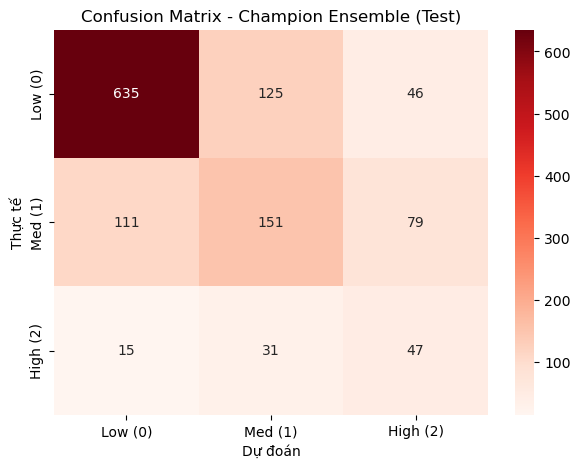

In [11]:
# # ==============================================================================
# # PART 6: ĐÁNH GIÁ TRÊN TẬP TEST (2019-2024)
# # ==============================================================================
# print("="*60)
# print("BÁO CÁO TRÊN TẬP TEST")
# print("="*60)

# # Dự đoán xác suất từ 3 models trên tập Test
# prob_xgb_test = model_xgb.predict_proba(X_test)
# prob_lgb_test = model_lgb.predict_proba(X_test)
# prob_cat_test = model_cat.predict_proba(X_test)

# # Blending xác suất với trọng số Optuna tốt nhất
# prob_champion_test = (best_w['w_xgb'] * prob_xgb_test + 
#                       best_w['w_lgb'] * prob_lgb_test + 
#                       w3_best * prob_cat_test)

# # Chọn nhãn chiến thắng bằng np.argmax (Class có xác suất cao nhất)
# y_pred_champion = np.argmax(prob_champion_test, axis=1)

# print("\n 1. Classification Report (Đa lớp):")
# print(classification_report(y_test, y_pred_champion, target_names=['Low Risk (0)', 'Medium Risk (1)', 'High Risk (2)']))

# auc_test = roc_auc_score(y_test, prob_champion_test, multi_class='ovr')
# print(f" 2. Multi-class ROC-AUC (OvR): {auc_test:.4f}")

# print("\n 3. Confusion Matrix (Tập Test):")
# cm = confusion_matrix(y_test, y_pred_champion)
# plt.figure(figsize=(7, 5))
# sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
#             xticklabels=['Low (0)', 'Med (1)', 'High (2)'], 
#             yticklabels=['Low (0)', 'Med (1)', 'High (2)'])
# plt.ylabel('Thực tế')
# plt.xlabel('Dự đoán')
# plt.title('Confusion Matrix - Champion Ensemble (Test)')
# plt.show()
# ==============================================================================
# PART 6: ĐÁNH GIÁ TRÊN TẬP TEST (2019-2024) - BẢN SỬA LỖI THRESHOLD
# ==============================================================================
print("="*60)
print("BÁO CÁO TRÊN TẬP TEST")
print("="*60)

# Dự đoán xác suất từ 3 models trên tập Test
prob_xgb_test = model_xgb.predict_proba(X_test)
prob_lgb_test = model_lgb.predict_proba(X_test)
prob_cat_test = model_cat.predict_proba(X_test)

# Blending xác suất với trọng số Optuna tốt nhất
prob_champion_test = (best_w['w_xgb'] * prob_xgb_test + 
                      best_w['w_lgb'] * prob_lgb_test + 
                      w3_best * prob_cat_test)

# KHÚC NÀY ĐÃ ĐƯỢC SỬA: Không dùng argmax nữa, tự gán Ngưỡng báo động
y_pred_champion = np.zeros(len(prob_champion_test))

# Thiết lập Ngưỡng (Threshold)
THRESHOLD_HIGH = 0.15  # Vượt 15% là báo động Đỏ
THRESHOLD_MED  = 0.30  # Vượt 30% là báo động Vàng

# Vòng lặp duyệt qua từng dòng dự đoán để gán nhãn
for i in range(len(prob_champion_test)):
    if prob_champion_test[i, 2] >= THRESHOLD_HIGH:
        y_pred_champion[i] = 2
    elif prob_champion_test[i, 1] >= THRESHOLD_MED:
        y_pred_champion[i] = 1
    else:
        y_pred_champion[i] = 0

print("\n 1. Classification Report (Đã điều chỉnh Threshold):")
print(classification_report(y_test, y_pred_champion, target_names=['Low Risk (0)', 'Medium Risk (1)', 'High Risk (2)']))

auc_test = roc_auc_score(y_test, prob_champion_test, multi_class='ovr')
print(f"\n 2. Multi-class ROC-AUC (OvR): {auc_test:.4f}")

print("\n 3. Confusion Matrix (Tập Test):")
cm = confusion_matrix(y_test, y_pred_champion)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Low (0)', 'Med (1)', 'High (2)'], 
            yticklabels=['Low (0)', 'Med (1)', 'High (2)'])
plt.ylabel('Thực tế')
plt.xlabel('Dự đoán')
plt.title('Confusion Matrix - Champion Ensemble (Test)')
plt.show()


## PART 7 — Explainable AI (Giải thích lý do Khủng hoảng)

Trong bài toán Đa lớp (Multi-class), SHAP sẽ trả về một `List` chứa 3 ma trận giải thích tương ứng cho 3 trạng thái. Chúng ta sẽ lọc lấy **ma trận số 3 (Index 2)** để ép AI phải giải thích xem: *"Dựa vào đâu mà mi dám phán Quốc gia này sẽ sụp đổ (High Risk)?"*


 Đang tính SHAP values cho XGBoost (Mất khoảng 30-60 giây)...


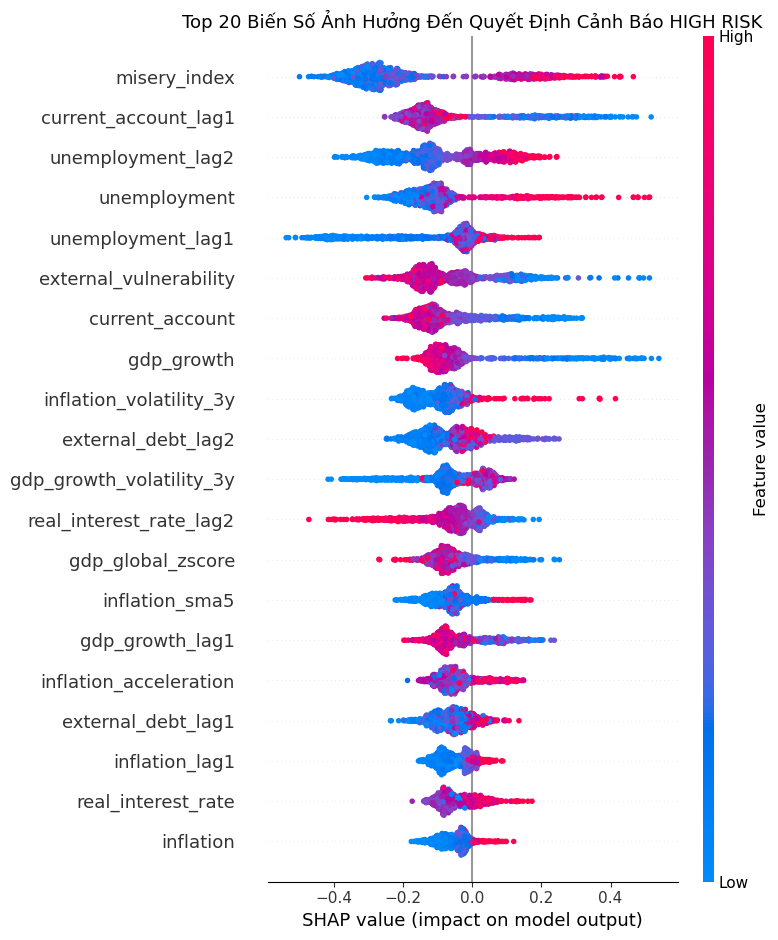

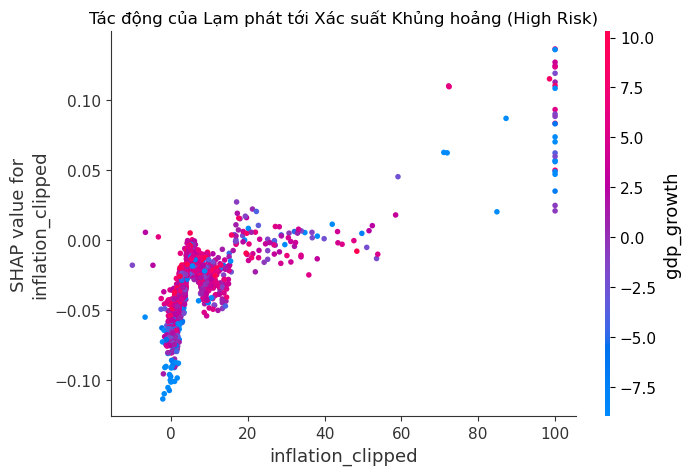


 Giải thích quyết định High Risk: Angola (Dự báo cho năm 2020)
    Xác suất báo động Đỏ: 29.1%


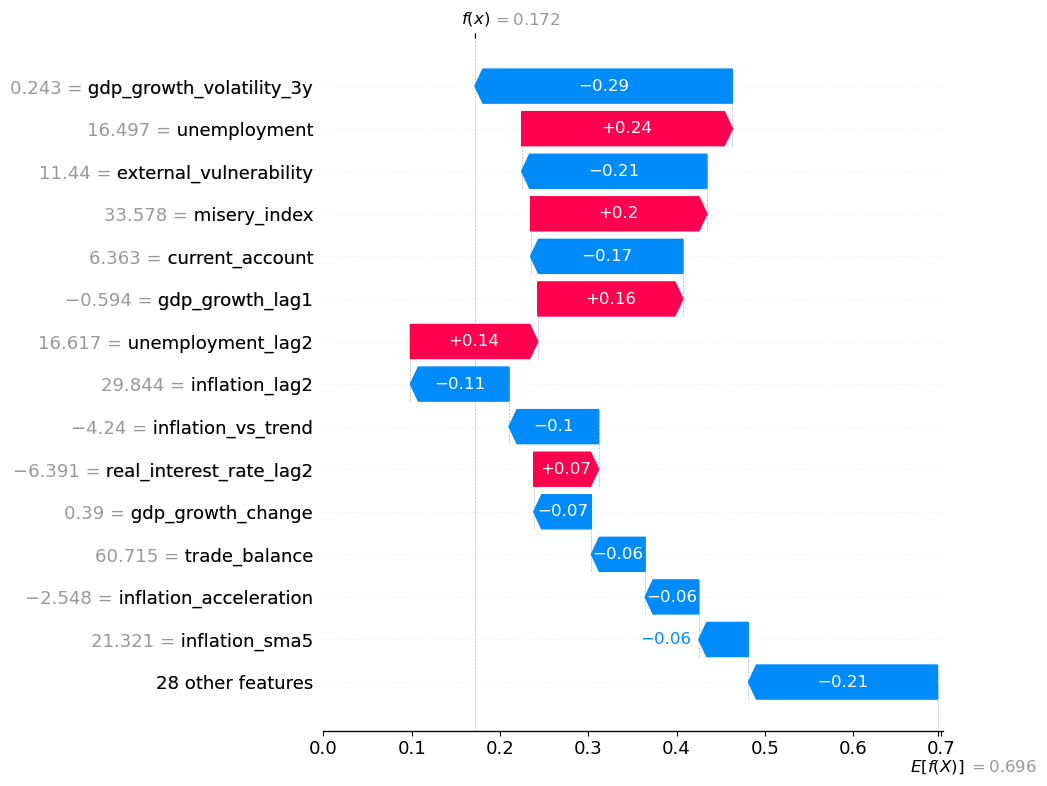

In [12]:
# ==============================================================================
# PART 7: EXPLAINABLE AI VỚI SHAP (BẢN CẬP NHẬT API MỚI)
# ==============================================================================


print(" Đang tính SHAP values cho XGBoost (Mất khoảng 30-60 giây)...")
explainer = shap.TreeExplainer(model_xgb)

# Dùng API mới của SHAP trả về đối tượng Explanation (Bao gồm cả base_values và data)
shap_obj = explainer(X_test)

# Trích xuất ma trận SHAP values của riêng Class 2 (High Risk)
# shap_obj.values có shape là (Số dòng, Số Features, Số Class)
shap_values_high_risk = shap_obj.values[:, :, 2]

# 1. Summary Plot cho High Risk
plt.figure()
shap.summary_plot(shap_values_high_risk, X_test, max_display=20, show=False)
plt.title("Top 20 Biến Số Ảnh Hưởng Đến Quyết Định Cảnh Báo HIGH RISK", fontsize=13)
plt.tight_layout()
plt.show()

# 2. Dependence Plot (Ví dụ với Lạm phát)
if 'inflation_clipped' in X_test.columns:
    shap.dependence_plot("inflation_clipped", shap_values_high_risk, X_test, show=False)
    plt.title("Tác động của Lạm phát tới Xác suất Khủng hoảng (High Risk)", fontsize=12)
    plt.show()

# 3. Waterfall Plot — Giải thích mổ xẻ 1 ca High Risk cụ thể
# Tìm ca nào mà thực tế là Khủng hoảng (2) và Model cũng rú còi Báo động (2)
crisis_indices = np.where((y_pred_champion == 2) & (y_test.values == 2))[0]

if len(crisis_indices) > 0:
    idx = crisis_indices[0] # Lấy ca đầu tiên tìm được
    country = test_df.iloc[idx]['country_name']
    year = test_df.iloc[idx]['year']

    print(f"\n Giải thích quyết định High Risk: {country} (Dự báo cho năm {year+1})")
    print(f"    Xác suất báo động Đỏ: {prob_champion_test[idx][2]*100:.1f}%")
    
    # Vẽ waterfall dùng thẳng object của class 2 cho sample idx
    plt.figure()
    shap.waterfall_plot(shap_obj[idx, :, 2], max_display=15, show=True)
else:
    print("\nKhông tìm thấy trường hợp dự đoán đúng High Risk trong tập Test.")


## PART 8 — Đóng Gói Model với MLflow

Bước cuối cùng của một AI Engineer: Đóng gói Champion Model, lưu kèm các trọng số của Ensemble, và Tracking tất cả tham số lên MLflow để tiện phục vụ triển khai API (FastAPI) sau này.


In [13]:
# ==============================================================================
# PART 8: ĐÓNG GÓI MODEL VỚI MLFLOW
# ==============================================================================
import mlflow
import mlflow.sklearn
import pickle

champion_path = f"{MODELS_DIR}/champion_model.pkl"
with open(champion_path, 'wb') as f:
    pickle.dump({
        'model_xgb': model_xgb,
        'model_lgb': model_lgb,
        'model_cat': model_cat,
        'weights': {'xgb': best_w['w_xgb'], 'lgb': best_w['w_lgb'], 'cat': w3_best},
        'feature_cols': FEATURE_COLS
    }, f)

print(f"\n💾 Đã lưu Champion Model tại: {champion_path}")

mlflow.set_tracking_uri("sqlite:///../mlflow.db")
mlflow.set_experiment("GDIP_MultiClass_Crisis_Classifier")

with mlflow.start_run(run_name="champion_weighted_blend_v2_multiclass"):
    # Log params
    mlflow.log_params({**best_w, 'w_cat': w3_best})
    mlflow.log_params(study_xgb.best_params)

    # Log metrics
    mlflow.log_metric("test_roc_auc_ovr", auc_test)
    mlflow.log_metric("test_macro_f1", f1_score(y_test, y_pred_champion, average='macro'))
    
    # Tránh lỗi nếu cv_scores ở trên chạy bị nan
    if 'valid_cv_scores' in locals() and len(valid_cv_scores) > 0:
        mlflow.log_metric("val_cv_auc_mean", np.mean(valid_cv_scores))
        mlflow.log_metric("val_cv_auc_std",  np.std(valid_cv_scores))

    # Log artifact
    mlflow.log_artifact(champion_path)
    mlflow.log_artifact(f"{MODELS_DIR}/best_params.json")

    run_id = mlflow.active_run().info.run_id
    print(f"✅ Đã log lên MLflow! Run ID: {run_id}")
    print("Mở terminal ở thư mục dự án và gõ `mlflow ui` để xem Dashboard quản lý AI.")



💾 Đã lưu Champion Model tại: ../airflow/dags/models/champion_model.pkl
✅ Đã log lên MLflow! Run ID: 15bb343b3bb6431fa5b6a73b3015d8d9
Mở terminal ở thư mục dự án và gõ `mlflow ui` để xem Dashboard quản lý AI.
